# Heart Disease Prediction Using Machine Learning

### Student Name: Archana Biradar
### Course: Data Analyst Master's Program
### Project: Capstone Project
### Date: July 2026

## Objective

The objective of this project is to analyze the Heart Disease dataset, identify the major factors contributing to cardiovascular disease, perform exploratory data analysis, and develop a Logistic Regression model capable of predicting the occurrence of heart disease.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
df = pd.read_excel("data.xlsx")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Heart Disease Prediction using Machine Learning

## Objective

The objective of this project is to analyze the factors responsible for cardiovascular disease (CVD) and develop a Logistic Regression model to predict the occurrence of heart disease based on patient health parameters.

In [6]:
# Shape of Dataset

print("Number of Rows and Columns:", df.shape)

Number of Rows and Columns: (303, 14)


In [7]:
# Column Names

df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
# Dataset Information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
# Missing Values

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
# Duplicate Records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 1


In [11]:
# Statistical Summary

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
# Remove duplicate records

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [13]:
# Check missing values

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Data Cleaning

- One duplicate record was identified and removed from the dataset.
- Missing values were checked, and no missing values were found.
- The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

## Statistical Summary

- The average age of patients is approximately **54 years**.
- The average resting blood pressure is around **131 mmHg**.
- The average cholesterol level is approximately **246 mg/dL**.
- The average maximum heart rate achieved is about **149 bpm**.
- The dataset contains patients aged **29 to 77 years**.

In [14]:
# Identify categorical variables

categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

print(categorical_columns)

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


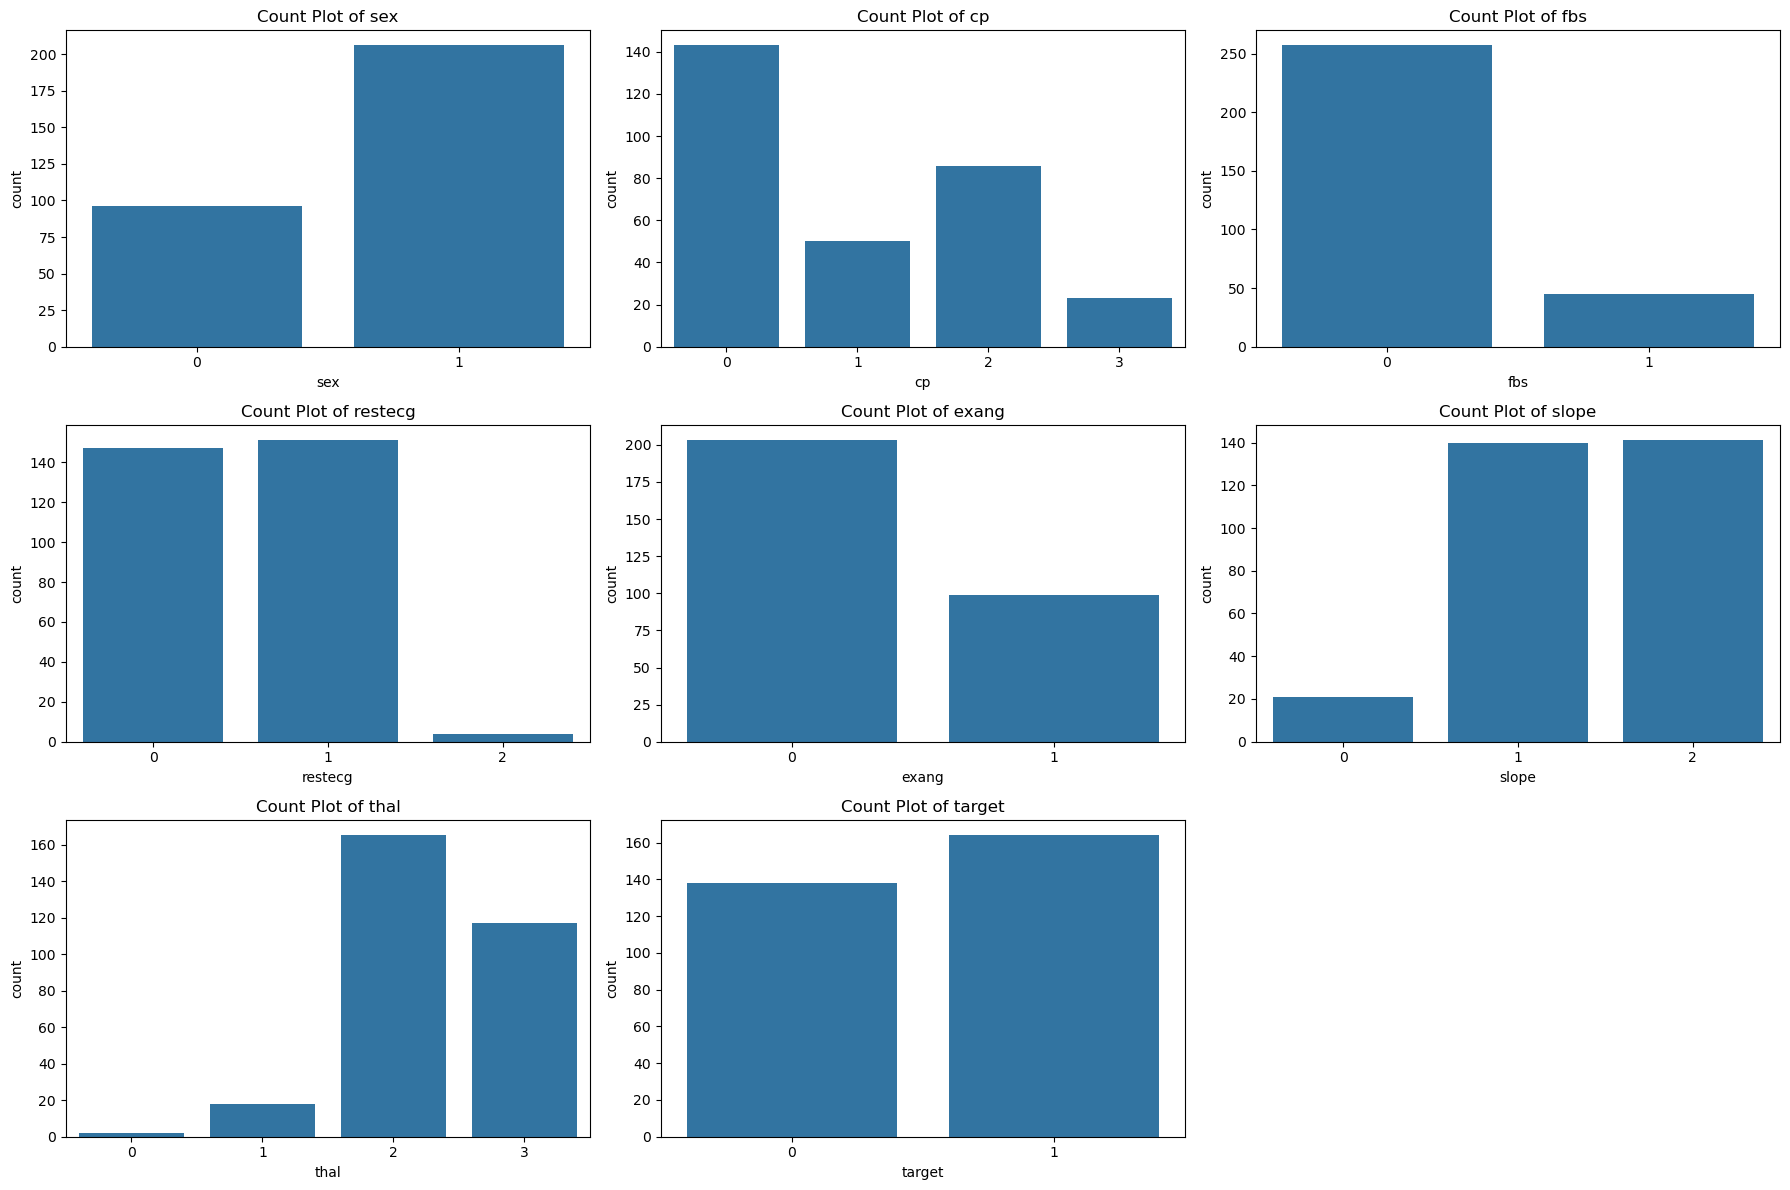

In [15]:
# Count plots for categorical variables

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')

plt.tight_layout()
plt.show()

## Occurrence of Heart Disease Across Different Ages

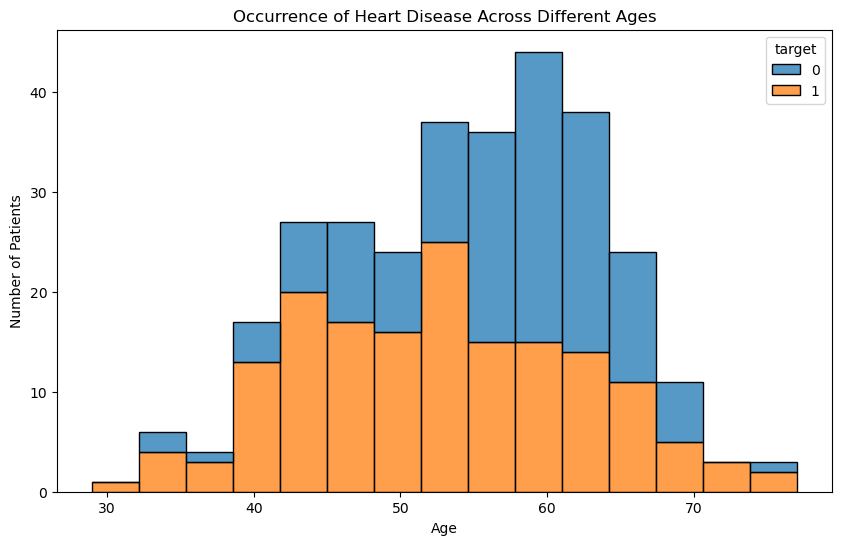

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='age', hue='target', bins=15, multiple='stack')

plt.title("Occurrence of Heart Disease Across Different Ages")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

### Interpretation

- Heart disease is observed across all age groups.
- The occurrence increases significantly after the age of 45.
- Patients between 50 and 65 years show the highest number of heart disease cases.

## Resting Blood Pressure Analysis

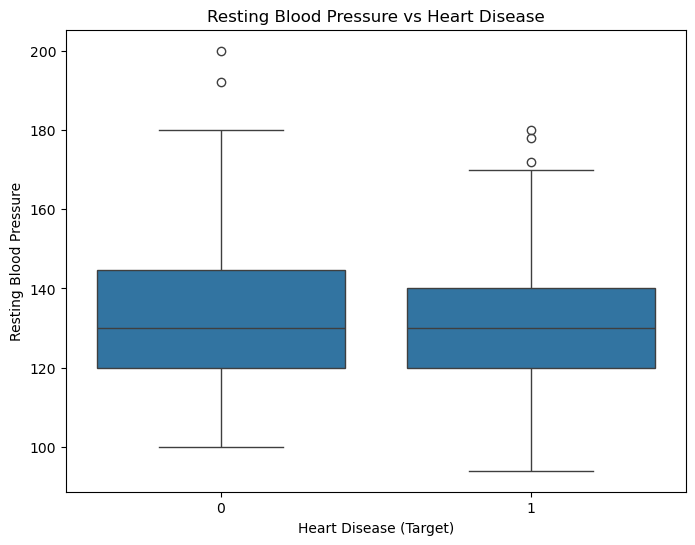

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(x='target', y='trestbps', data=df)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.xlabel("Heart Disease (Target)")
plt.ylabel("Resting Blood Pressure")

plt.show()

### Interpretation

- Patients with heart disease generally show greater variation in resting blood pressure.
- Several outliers are present, indicating unusually high blood pressure values.
- Resting blood pressure alone may not be sufficient for prediction but contributes to cardiovascular risk assessment.

## Gender Composition

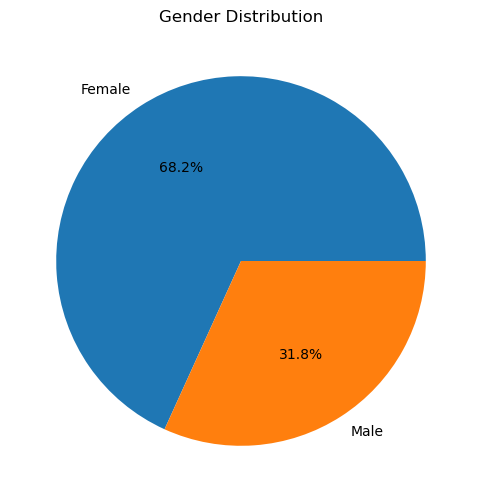

In [18]:
plt.figure(figsize=(6,6))

df['sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Female','Male']
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

### Interpretation

- The dataset contains a higher proportion of male patients than female patients.
- This indicates that more male patients were included in the study population.

# Relationship Between Cholesterol Levels and Heart Disease

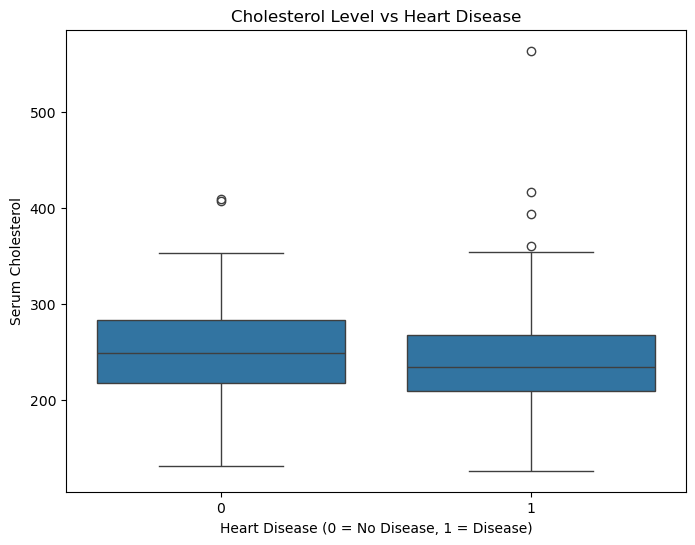

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(x='target', y='chol', data=df)

plt.title("Cholesterol Level vs Heart Disease")
plt.xlabel("Heart Disease (0 = No Disease, 1 = Disease)")
plt.ylabel("Serum Cholesterol")

plt.show()


### Interpretation

- Patients with heart disease generally exhibit a wider range of cholesterol levels.
- High cholesterol is considered an important risk factor for cardiovascular disease.
- However, cholesterol alone cannot accurately predict heart disease.

### Correlation Heatmap

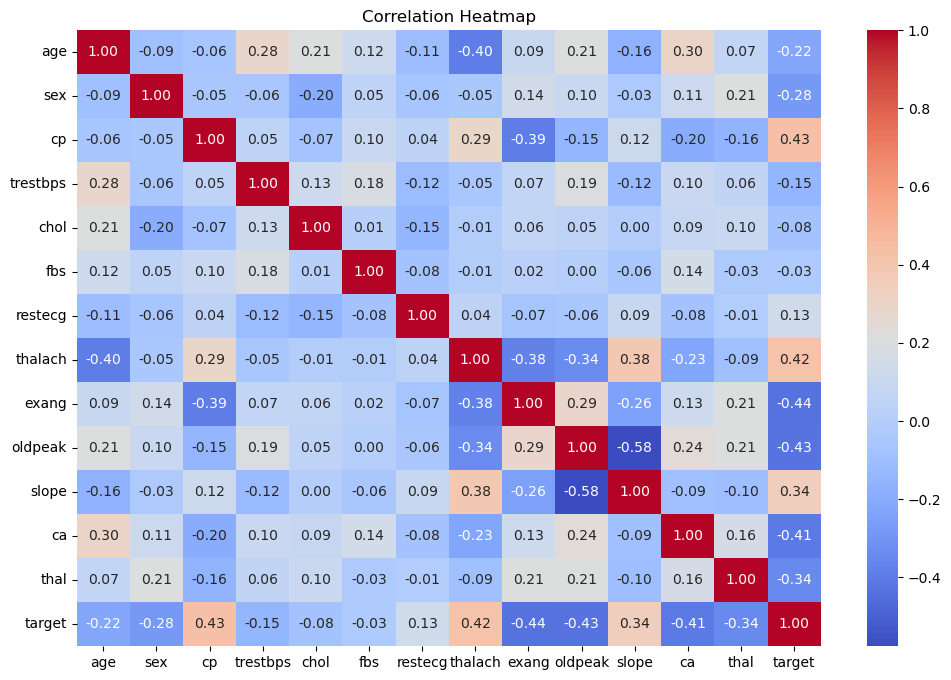

In [46]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap illustrates the correlation among all variables. Features with stronger positive or negative correlations with the target variable are likely to have greater influence on predicting heart disease.

# Relationship Between Peak Exercise (Oldpeak) and Heart Disease

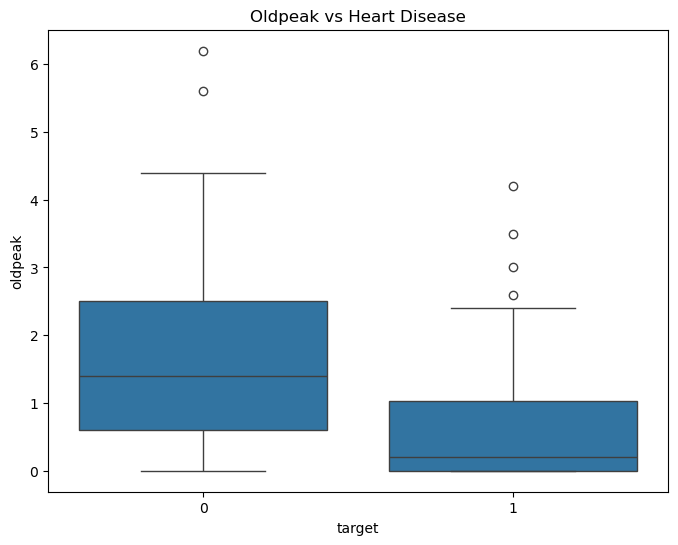

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(x='target', y='oldpeak', data=df)

plt.title("Oldpeak vs Heart Disease")

plt.show()

### Interpretation

- Patients with heart disease tend to have higher Oldpeak values.
- Higher ST depression during exercise indicates a greater possibility of cardiovascular disease.

# Effect of Thalassemia on Heart Disease

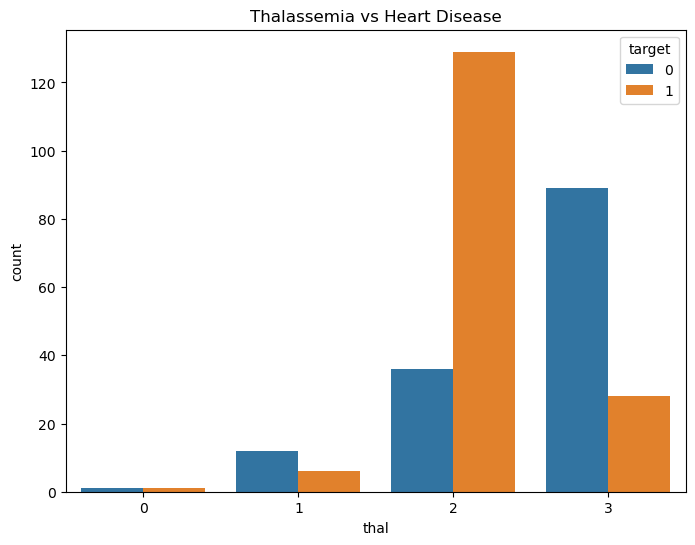

In [21]:
plt.figure(figsize=(8,6))

sns.countplot(x='thal', hue='target', data=df)

plt.title("Thalassemia vs Heart Disease")

plt.show()

### Interpretation

- Certain Thalassemia categories have a greater proportion of heart disease patients.
- Thalassemia appears to be an important factor in predicting cardiovascular disease.

# Pair Plot

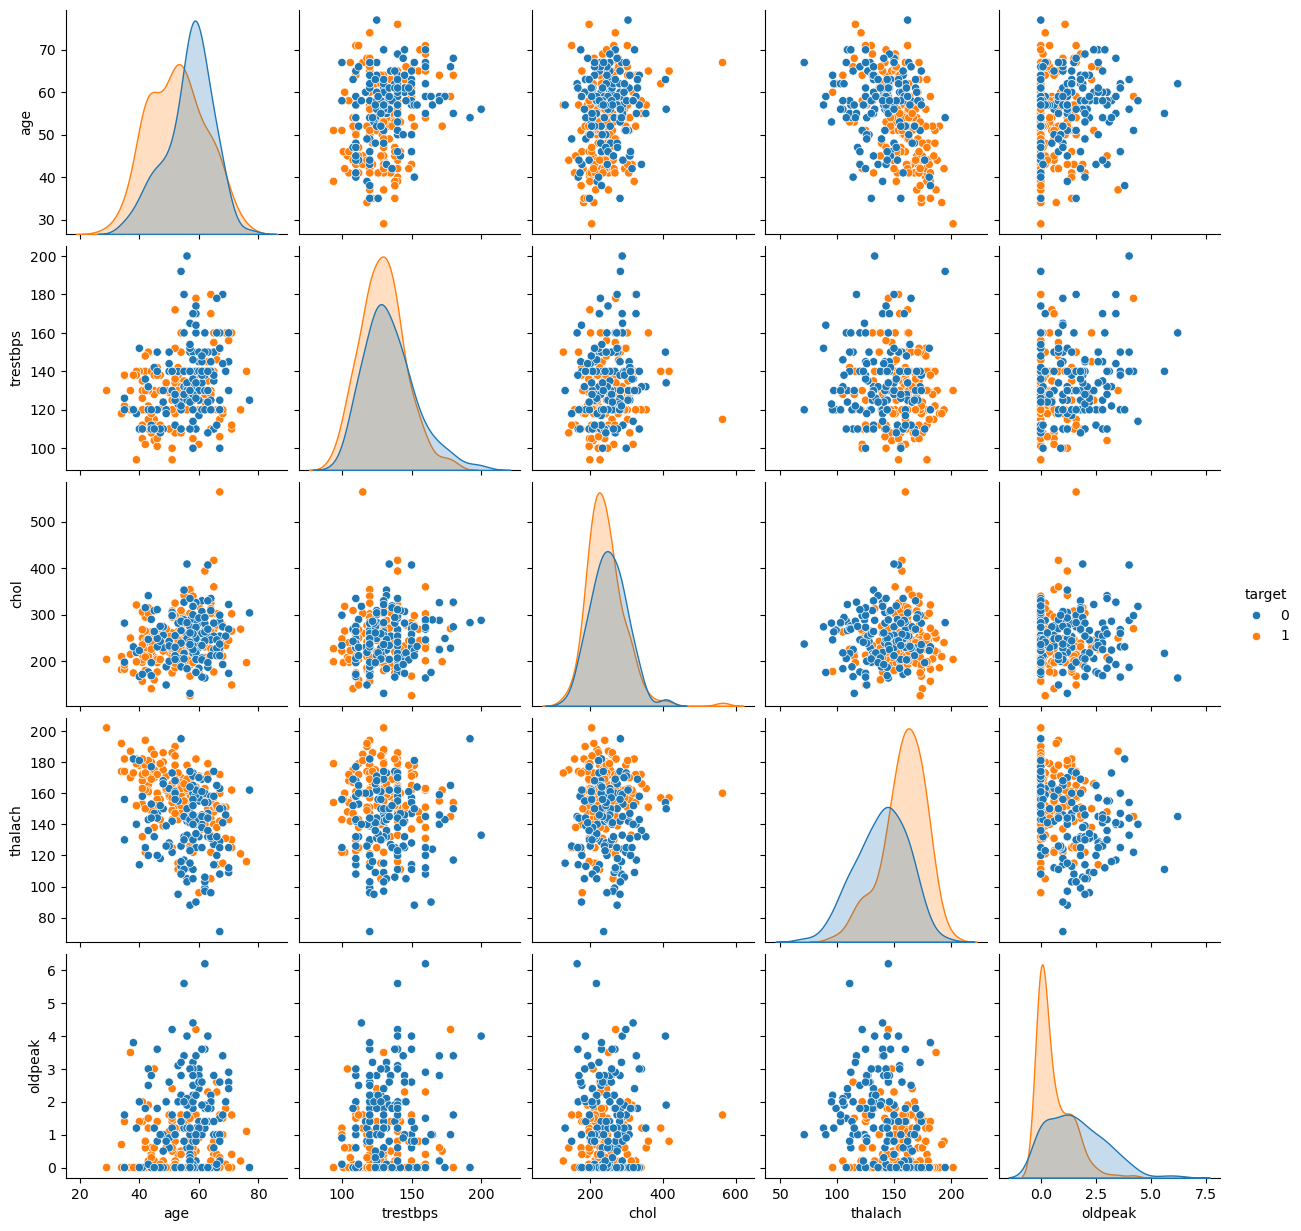

In [23]:
sns.pairplot(
    df,
    hue='target',
    vars=['age','trestbps','chol','thalach','oldpeak']
)

plt.show()

### Interpretation

The pair plot shows the relationship among important numerical variables.

It helps identify patterns, clusters, and possible correlations associated with heart disease.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# Logistic Regression Model

In [29]:
X = df.drop("target", axis=1)

y = df["target"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [36]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [37]:
y_pred = model.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 81.97 %


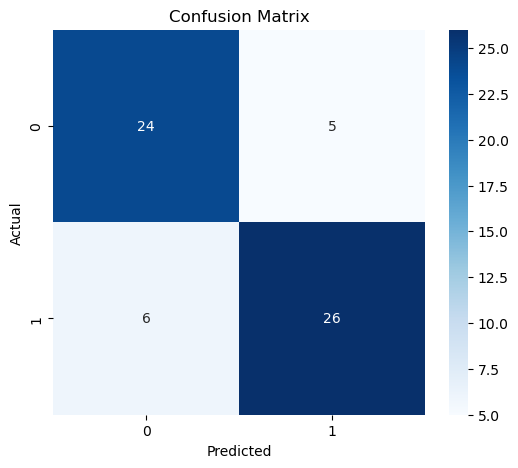

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



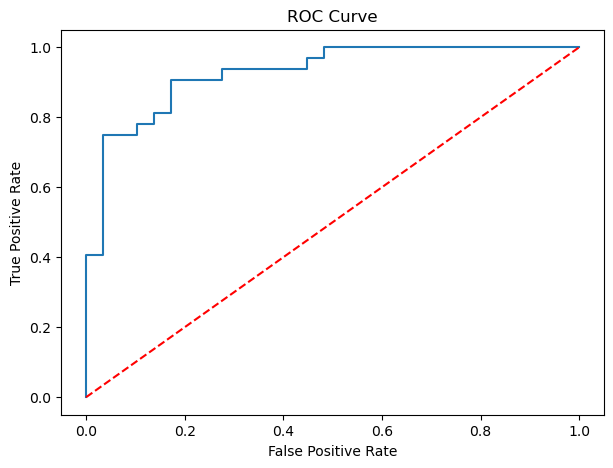

ROC-AUC Score : 0.9267241379310345


In [41]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

print("ROC-AUC Score :", roc_auc_score(y_test,y_prob))

### Comparing Actual vs Predicted Values

In [47]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
180,0,0
229,0,0
111,1,1
247,0,0
60,1,1
9,1,1
119,1,1
224,0,0
268,0,0
33,1,0


In [48]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,cp,0.676635
7,thalach,0.519792
10,slope,0.489631
6,restecg,0.270409
5,fbs,0.163625
0,age,0.007483
4,chol,-0.201407
3,trestbps,-0.453359
8,exang,-0.492516
9,oldpeak,-0.510700


# Conclusion

### Findings

- The dataset contained 303 observations and 14 attributes.
- One duplicate record was identified and removed.
- No missing values were found.
- Age is an important factor influencing heart disease.
- Patients with higher cholesterol levels tend to have an increased risk of heart disease.
- Higher Oldpeak values are strongly associated with cardiovascular disease.
- Thalassemia is one of the significant predictors of heart disease.
- Logistic Regression successfully classified patients into diseased and healthy categories with good accuracy.

### Business Recommendation

Healthcare organizations can use predictive models to identify high-risk patients at an early stage. Early diagnosis enables preventive treatment, lifestyle modification, and continuous monitoring, thereby reducing the risk of severe cardiovascular events.